# Different difficulty factors

In [1]:
import sys
sys.path.append("..")

In [2]:
import cupy
_ = cupy.cuda.get_local_runtime_version()
sain_runtime = cupy.cuda.runtime

import torch
_ = torch.cuda.is_available()

from gbgpu.gbgpu import GBGPU
cupy.cuda.runtime = sain_runtime

from src.noise import AnalyticNoise
from src.sampling import sample_gb_parameters_uniform

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator

from config import dt, Tobs, f0_center

%load_ext autoreload
%autoreload 2

Dataset will be saved to: data/synthetic_smalltest_gb_dataset as dataset.hdf5


In [ ]:
def plot_difficulty_comparison(A_easy, starts_easy, A_hard, starts_hard, df):
    N_easy = A_easy.shape[1]
    N_hard = A_hard.shape[1]
    
    amp_easy = np.abs(A_easy)
    amp_hard = np.abs(A_hard)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    for i in range(amp_easy.shape[0]):
        freqs_i = (starts_easy[i] + np.arange(N_easy)) * df
        ax1.plot(freqs_i, amp_easy[i], label=f"Wave {i+1}", alpha=0.8, linewidth=1.5)
        
    ax1.set_title(f"Difficulty Factor 10 (N = {N_easy}): Spread over a wide window", fontsize=14)
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude |A|")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.12, 1))
    
    for i in range(amp_hard.shape[0]):
        freqs_i = (starts_hard[i] + np.arange(N_hard)) * df
        ax2.plot(freqs_i, amp_hard[i], label=f"Wave {i+1}", alpha=0.8, linewidth=1.5)
        
    ax2.set_title(f"Difficulty Factor 1 (N = {N_hard}): Congestion in a narrow window", fontsize=14)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Amplitude |A|")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.12, 1))

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))
    
    ax1.xaxis.set_major_formatter(formatter)
    ax2.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

In [4]:
nb_samples = 10
df = 1.0 / Tobs

In [5]:
params_hard, nb_samples, actual_N = sample_gb_parameters_uniform(nb_samples, force_difficulty_factor=1)
print(f"Shape of the parameters for hard difficulty: {params_hard.shape}\nNumber of samples: {nb_samples}\nActual N used: {actual_N}")

gb_hard = GBGPU(force_backend="cuda")
gb_hard.run_wave(*params_hard, N=actual_N, dt=dt, T=Tobs)


A_complex_hard = gb_hard.A.get()
starts_hard = gb_hard.start_inds.get()

Shape of the parameters for hard difficulty: (9, 10)
Number of samples: 10
Actual N used: 128


In [6]:
params_easy, nb_samples, actual_N  = sample_gb_parameters_uniform(nb_samples)
print(f"Shape of the parameters for easy difficulty: {params_easy.shape}\nNumber of samples: {nb_samples}\nActual N used: {actual_N}")

gb_easy = GBGPU(force_backend="cuda")
gb_easy.run_wave(*params_easy, N=actual_N, dt=dt, T=Tobs)

A_complex_easy = gb_easy.A.get()
starts_easy = gb_easy.start_inds.get()

Shape of the parameters for easy difficulty: (9, 10)
Number of samples: 10
Actual N used: 1280


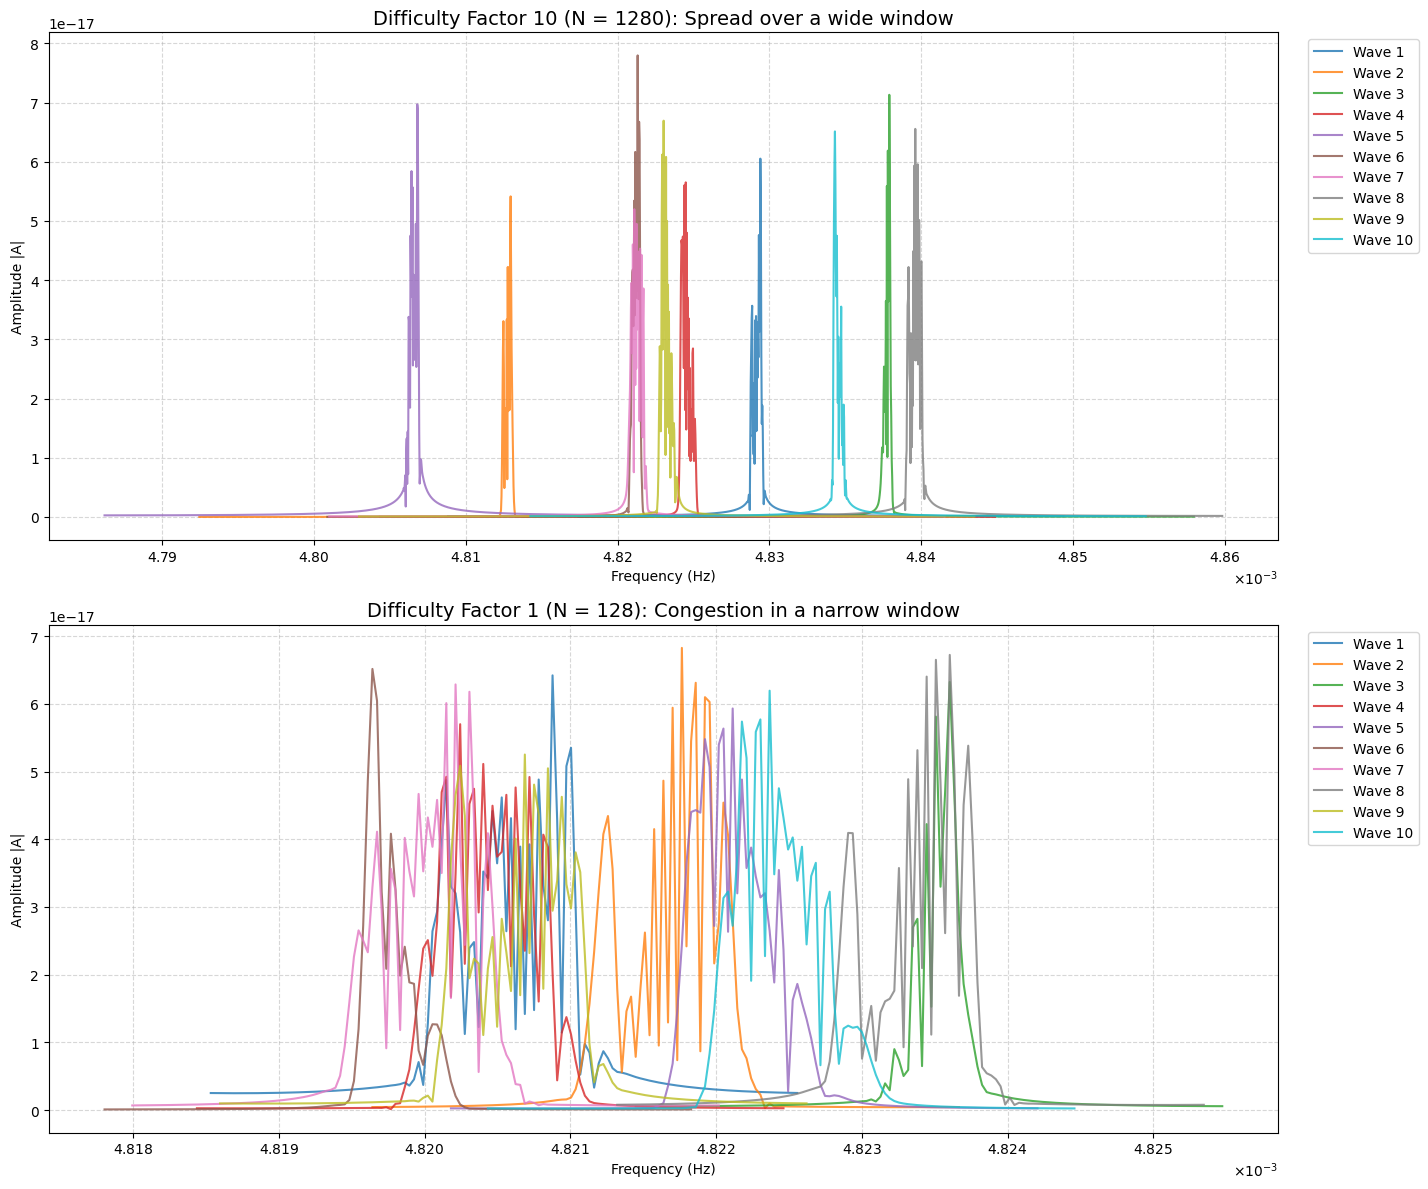

In [7]:
plot_difficulty_comparison(A_complex_easy, starts_easy, A_complex_hard, starts_hard, df)